<a href="https://colab.research.google.com/github/Birlinha/AlienHunting/blob/main/GravitationalWaves_condensed(GW170817).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dependências do Projeto

In [6]:
# -- Uncomment following line if running in Google Colab
#! pip install -q PyCBC lalsuite --quiet
#! pip install gwosc --quiet
#! pip install gwpy --quiet
#! pip install matplotlib==2.0.2 --quiet

     |████████████████████████████████| 7.0 MB 17.4 MB/s 
     |████████████████████████████████| 48.3 MB 1.5 MB/s 
     |████████████████████████████████| 45 kB 3.3 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 7.3 MB 22.9 MB/s 
     |████████████████████████████████| 45 kB 3.2 MB/s 
     |████████████████████████████████| 201 kB 65.8 MB/s 
     |████████████████████████████████| 1.4 MB 51.5 MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 51 kB 8.7 MB/s 
     |████████████████████████████████| 78 kB 7.5 MB/s 
     |████████████████████████████████| 55 kB 4.9 MB/s 
     |████████████████████████████████| 295 kB 67.6 MB/s 
     |████████████████████████████████| 43 kB 1.7 MB/s 
  Installing build dependencies ... done
  Getting requirements 

In [17]:
import gwosc
from gwosc import datasets

import gwpy
from gwpy.timeseries import TimeSeries

# Como obter informação sobre uma onda gravitacional

In [3]:
event = "GW170817-v3"

In [4]:
# here we are asking the ligo lab when did GW170817 happen (gps time)
event_gps = datasets.event_gps(event)

In [5]:
# here we are asking what detectors were available during that TimeFrame
detectors_list = datasets.event_detectors(event)

In [6]:
dataStream = []

# fetch detectors lab data
for det in detectors_list:
  data = TimeSeries.fetch_open_data(det, int(event_gps)-512, int(event_gps)+512, cache=True, sample_rate=4096)
  dataStream.append(data)

In [17]:
i = 0 ## index
for data in dataStream:
  print("----------------------------------------------")
  print("          Dados do evento")
  print(data)
  # print(" t0 = {}".format(     data.t0.to_value()))
  # print(" dt = {}".format(     data.dt.to_value()))
  i += 1

----------------------------------------------
          Dados do evento
TimeSeries([-1.88883673e-12, -1.87792628e-12, -1.86701162e-12,
            ..., -1.89664184e-12, -1.90214859e-12,
            -1.90766812e-12]
           unit: dimensionless,
           t0: 1187008370.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)
----------------------------------------------
          Dados do evento
TimeSeries([-7.18222602e-19, -7.05033785e-19, -7.07535971e-19,
            ...,  4.56565218e-19,  4.61036938e-19,
             4.58236436e-19]
           unit: dimensionless,
           t0: 1187008370.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)
----------------------------------------------
          Dados do evento
TimeSeries([5.73571971e-19, 5.79616885e-19, 5.76818759e-19, ...,
            4.70957633e-19, 4.58255672e-19, 4.61226401e-19]
           unit: dimensionless,
           t0: 1187008370.0 s,
           dt

![Kronos e Kairós](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRRopojjXZC4L8jezndUIcCq56bnp-4Ycx8s4B3M3efMb-mD5B4sz9UrL7tmhO62sOgL_I&usqp=CAU)

Os gregos utilizavam duas palavras para o tempo: Cronos e Kairós. Essas palavras significavam o tempo, porém de maneiras distintas

Isso porque Cronos se referia ao tempo sequencial, cronológico, aquele que se mede. Já Kairós era o momento, algo indeterminado no tempo, um acontecimento especial ou uma experiência oportuna.

## Cronos

O tempo cronológico em nosso projeto é muito específico e preciso - por conta da natureza do problema que é a identificação de buracos negros. Em ciência de dados, muitas vezes vamos ouvir falar do termo "sample rate" - que determina quantas informações temos de um determinado fenômeno

Veja o gráfico:

<img src="https://i.ytimg.com/vi/5NE3Cx0PClc/maxresdefault.jpg" height="400px"></img>

## Kairós

O momento oportuno - o evento que queremos captar é a onda gravitacional

Registrar o momento em que esses acontecem nos ajuda a tirar mais conclusões sobre eles e aprender como funcionam

# As ferramentas dos Cientistas de Dados Astrofísicos

As técnicas que os cientistas usam para detectar, compreender, e transformar os dados dod estudos da LIGO são diversas

Uma pequena pesquisa no google sobre como essas ferramentas funcionam, e eu rapidamente me encontrei estudando as ferramentas das ferramentas

Mas essas são as mais comuns, e que estão dentro das próprias bibliotecas do laboratório "gwosc" e "gwpy"

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
def fetch_EventData(event):
  # here we are asking the ligo lab when did GW170817 happen (gps time)
  event_gps = datasets.event_gps(event)
  # here we are asking what detectors were available during that TimeFrame
  detectors_list = datasets.event_detectors(event)

  df = pd.DataFrame()

  # fetch detectors lab data
  for det in detectors_list:
    data = TimeSeries.fetch_open_data(det, int(event_gps)-512, int(event_gps)+512, cache=True)
    dfDet = pd.DataFrame(data)
    dfDet = dfDet.rename({"Strain":str(det)}, axis='columns')
    
    df = df.join(dfDet,how="right")

  return df

In [20]:
df = fetch_EventData("GW170817-v3")

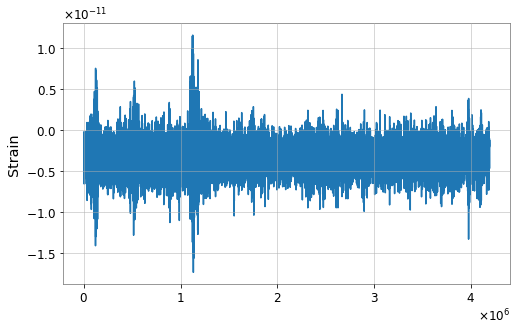

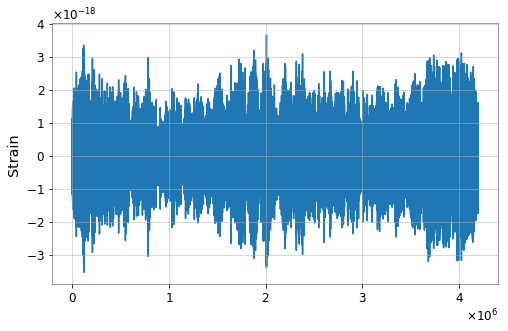

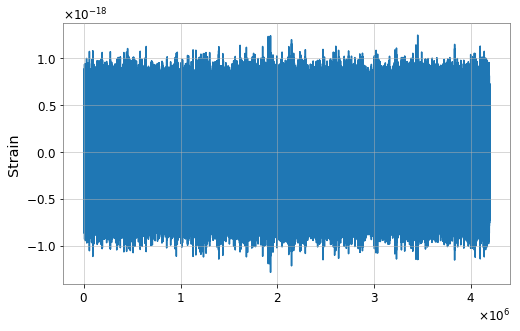

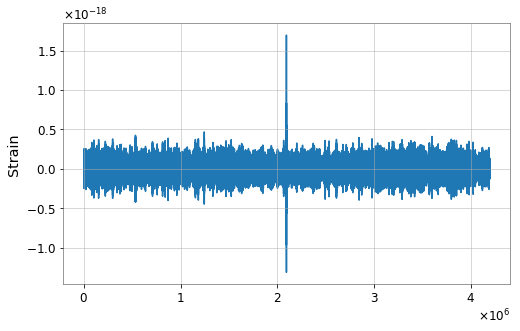

In [21]:
plot = df["G1"].plot(figsize=(8, 4.8), ylabel='Strain')
plt.show()

plot = df["V1"].plot(figsize=(8, 4.8), ylabel='Strain')
plt.show()

plot = df["H1"].plot(figsize=(8, 4.8), ylabel='Strain')
plt.show()

plot = df["L1"].plot(figsize=(8, 4.8), ylabel='Strain')
plt.show()

# Ondas

O sinal recebido pode ter diversas origens
Normalmente, olhando para o sinal é possível encontrar algumas informações importantes para determinar sua fonte

Alguns tipos de sinais:
- Senoidal

<img src="https://technomaster.com.br/wp-content/uploads/2020/06/senoidal-pura.png" height="100px"></img>

- Rampa (normalmente utilizado para sistemas que estão perdendo energia ao longo do tempo, como molas)

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Exponential_loss_blue.svg/375px-Exponential_loss_blue.svg.png" height="100px"></img>

Em nosso caso, a rampa será ao contrário a onda gravitacional atinge seu maior ponto quando dois corpos celestiais se unem, e se parece mais ou menos assim:

In [22]:
from pycbc.waveform import get_td_waveform
import pylab

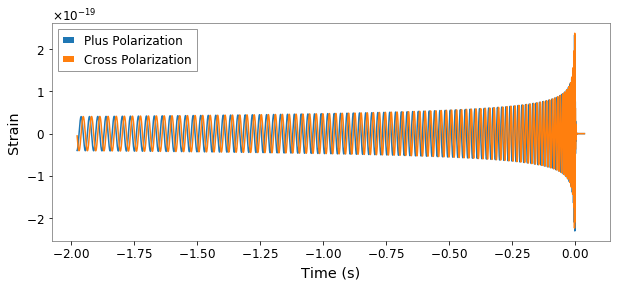

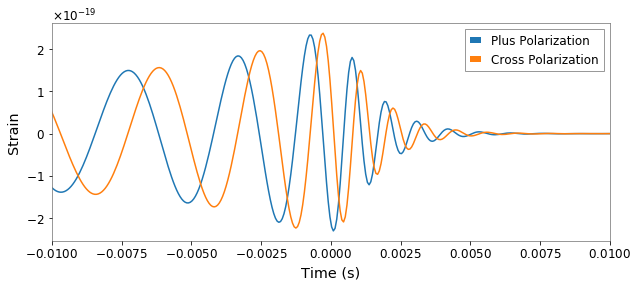

In [41]:
# The outputs of this function are the "plus" and "cross" polarizations 
# of the gravitational-wave signal as viewed from the line of sight at 
# a given source inclination (assumed face-on, i.e. zero inclination
# if not provided)
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=10,
                         mass2=10,
                         delta_t=1.0/16384,
                         f_lower=30)

pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.legend()
pylab.grid()
pylab.show()

# Zoom in near the merger time
pylab.figure(figsize=pylab.figaspect(0.4))
pylab.plot(hp.sample_times, hp, label='Plus Polarization')
pylab.plot(hp.sample_times, hc, label='Cross Polarization')
pylab.xlabel('Time (s)')
pylab.ylabel('Strain')
pylab.xlim(-.01, .01)
pylab.legend()
pylab.grid()
pylab.show()

![](https://physics.aps.org/assets/8c60cd69-5366-49d1-b1cf-53fce4303a14/e52_2.png)

# Cálculo da precisão dos instrumentos de medição (fourier transform)

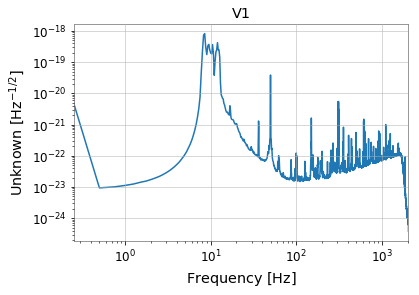

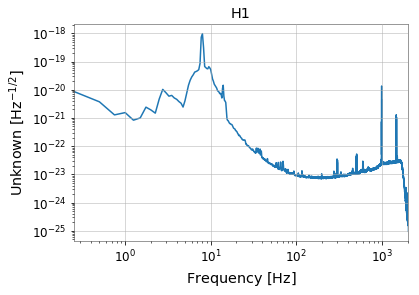

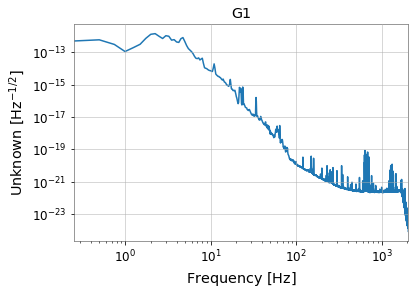

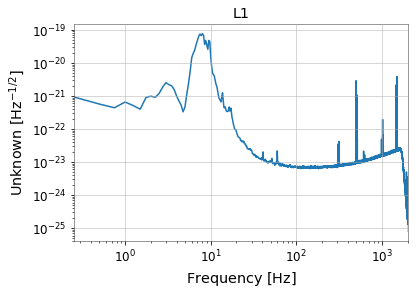

In [24]:
event = "GW170817-v3"
# here we are asking the ligo lab when did GW170817 happen (gps time)
event_gps = datasets.event_gps(event)
# here we are asking what detectors were available during that TimeFrame
detectors_list = datasets.event_detectors(event)

for det in detectors_list:
  data = TimeSeries.fetch_open_data(det, int(event_gps)-512, int(event_gps)+512, cache=True)
  asd_data = data.asd(fftlength=4, method="median")

  p = asd_data.plot()

  plt.title(det)
  plt.show()

/usr/local/lib/python3.7/dist-packages/gwpy/signal/qtransform.py:126: UserWarning: upper frequency of 2000.00 is too high for the given Q range, resetting to 1979.19
  % (self.frange[1], maxf))


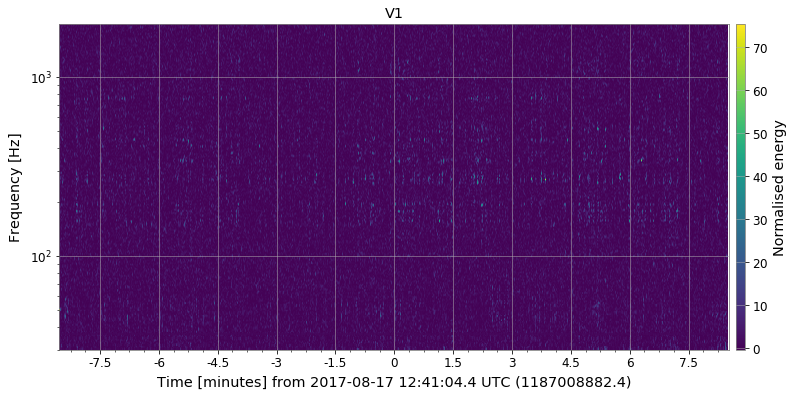

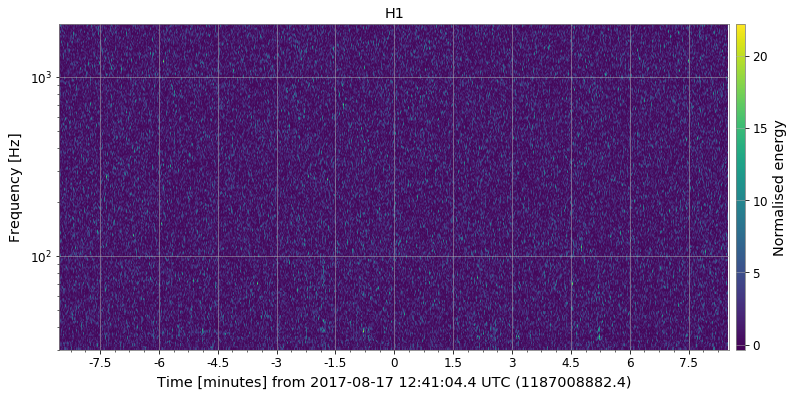

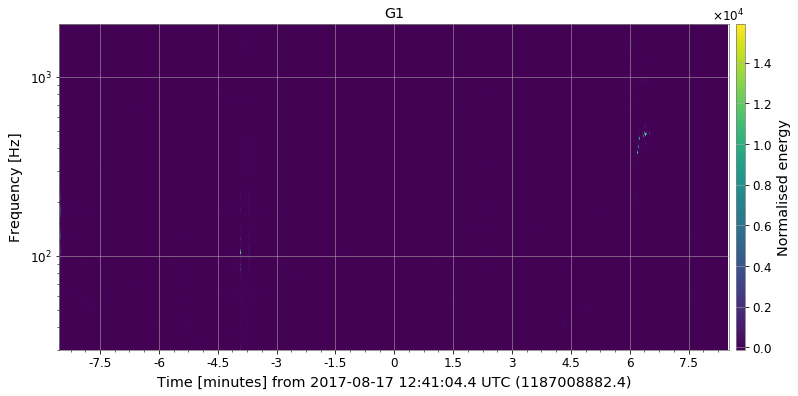

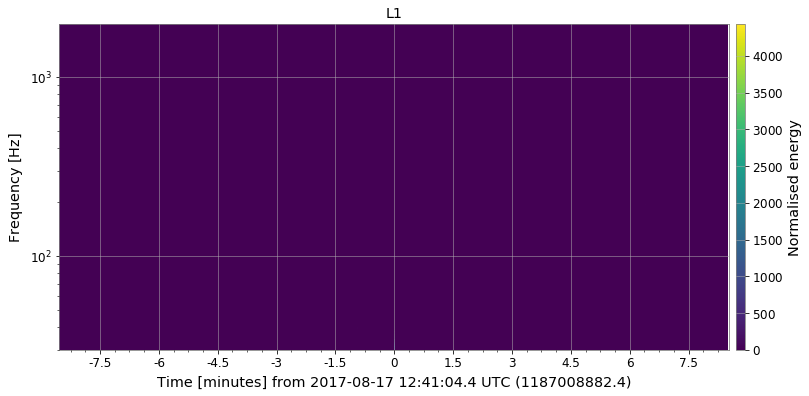

In [27]:
event = "GW170817-v3"
# here we are asking the ligo lab when did GW170817 happen (gps time)
event_gps = datasets.event_gps(event)
# here we are asking what detectors were available during that TimeFrame
detectors_list = datasets.event_detectors(event)

for det in detectors_list:
  data = TimeSeries.fetch_open_data(det, int(event_gps)-512, int(event_gps)+512, cache=True)

  #addind q-transform
  qt = data.q_transform(frange=(30,2000), qrange=(70,130))
  p = qt.plot()

  ax = p.gca()
  ax.set_epoch(event_gps)
  ax.set_yscale('log')
  ax.colorbar(label="Normalised energy")

  plt.title(det)
  plt.show()